# Modelling step

In this notebook, we will use the preprocessed dataset produced previously to train and evaluate two different regression models.

Both of these model will predict the target `wage_gap` (the proportional female-male wage gap) based on the values of the six prepared input features:
* `education_gap`
* `employment_gap`
* `native_gap`
* `immigrant_gap`
* `gdp_pc`
* `part_time_gap`

The first model is a Decision Tree. The second is a Neural Network with two hidden layers, following a pyramid structure design.

Note that the input features for the Neural Network model have been scaled according to a MinMax technique, given that, unlike the Decision Tree, this type of model is sensitive to the scale of the input data.

The same 70-30 train-test split datasets were used to train and evaluate both models, in order to ensure that the results are comparable.

## Imports and definitions

In [1]:
import copy
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import tqdm
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeRegressor, plot_tree

In [2]:
target = "wage_gap"

features = [
    "education_gap",
    "employment_gap",
    "native_gap",
    "immigrant_gap",
    "gdp_pc",
    "part_time_gap"
]

train_size = 0.7

In [3]:
# Set all random seeds for reproducibility

random_seed_value = 48

np.random.seed(random_seed_value)
torch.manual_seed(random_seed_value)

## Creation of the train and test datasets

In [4]:
df = pd.read_csv("../data/FINAL_DATASET.csv")

display(df.dtypes)
display(df.head(2))

country            object
year                int64
wage_gap          float64
education_gap     float64
employment_gap    float64
native_gap        float64
immigrant_gap     float64
gdp_pc            float64
part_time_gap     float64
dtype: object

,country,year,wage_gap,education_gap,employment_gap,native_gap,immigrant_gap,gdp_pc,part_time_gap
0,Australia,2010,20.381232,-6.382107,16.347199,11.279961,17.517487,122.776402,-43.772
1,Australia,2011,19.458304,-7.470135,16.211098,10.694275,17.213684,123.987878,-44.942


In [5]:
df.describe()

,year,wage_gap,education_gap,employment_gap,native_gap,immigrant_gap,gdp_pc,part_time_gap
count,518.000000,518.000000,518.000000,518.000000,518.000000,518.000000,518.000000,518.000000
mean,2016.500000,16.186115,-5.962259,12.929759,10.280404,15.599538,103.742656,-41.136133
std,4.035026,6.487558,6.693212,8.393347,6.884498,6.062943,41.927910,12.876995
min,2010.000000,-0.297029,-22.699179,-1.606552,0.028450,3.563530,33.441652,-70.858000
25%,2013.000000,11.954341,-10.503915,7.584916,5.806147,12.000000,77.121355,-51.396250
50%,2016.500000,16.003406,-6.063821,10.766654,8.014072,15.398693,97.860996,-40.520000
75%,2020.000000,19.944810,-1.833586,15.455013,12.939880,18.050714,126.914642,-30.754250
max,2023.000000,37.043847,12.610080,39.104080,36.464100,38.286648,287.736306,-14.630000


In [6]:
X = df[features].values
y = df[target].values

print(X.shape, y.shape)

(518, 6) (518,)


In [7]:
# Split data to be used for model training and for testing

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=train_size, shuffle=True)

print(
    f"Row count in training set: {X_train.shape[0]}",
    f"Row count in test set:     {X_test.shape[0]}",
    f"Proportion:                {round(X_train.shape[0] / (X_train.shape[0] + X_test.shape[0]), 2)}",
    sep="\n",
)

Row count in training set: 362
Row count in test set:     156
Proportion:                0.7


In [8]:
# Scale input features for the Neural Network

scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(
    f"Input feature minimum values: scaled from {np.min(X_train)} to {np.min(X_train_scaled)}",
    f"Input feature maximum values: scaled from {np.max(X_train)} to {np.max(X_train_scaled)}",
    sep="\n",
)

Input feature minimum values: scaled from -70.858 to 0.0
Input feature maximum values: scaled from 287.736306 to 1.0


## Train Decision Tree

In [9]:
# Random search to determine best model hyperparameters

param_search_space = {
    "max_depth": list(range(2, 10)),
    "min_samples_leaf": list(range(5, 20)),
}

model = DecisionTreeRegressor()

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_search_space,
    n_iter=100,
    scoring="neg_root_mean_squared_error",
    cv=3,
)

random_search.fit(X_train, y_train)

# RandomizedSearchCV returns the negative of the RMSE because it needs to maximize it
best_score = abs(random_search.best_score_)
best_params = random_search.best_params_

print(
    f"Best hyperparameters: {random_search.best_params_}",
    f"Best RMSE score:      {best_score}",
    sep="\n",
)

Best hyperparameters: {'min_samples_leaf': 6, 'max_depth': 9}
Best RMSE score:      4.108192519342524


In [10]:
# Train model with the best hyperparameters found

model = DecisionTreeRegressor(**best_params)
model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,9
,min_samples_split,2
,min_samples_leaf,6
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [11]:
# Display evaluation metrics

y_pred_train = model.predict(X_train)
rmse_train = mean_squared_error(y_train, y_pred_train) ** 0.5

y_pred_test = model.predict(X_test)
rmse_test = mean_squared_error(y_test, y_pred_test) ** 0.5

print(
    f"RMSE on train dataset: {rmse_train:.4f}",
    f"RMSE on test dataset: {rmse_test:.4f}",
    sep="\n",
)

RMSE on train dataset: 2.6460
RMSE on test dataset: 5.0598


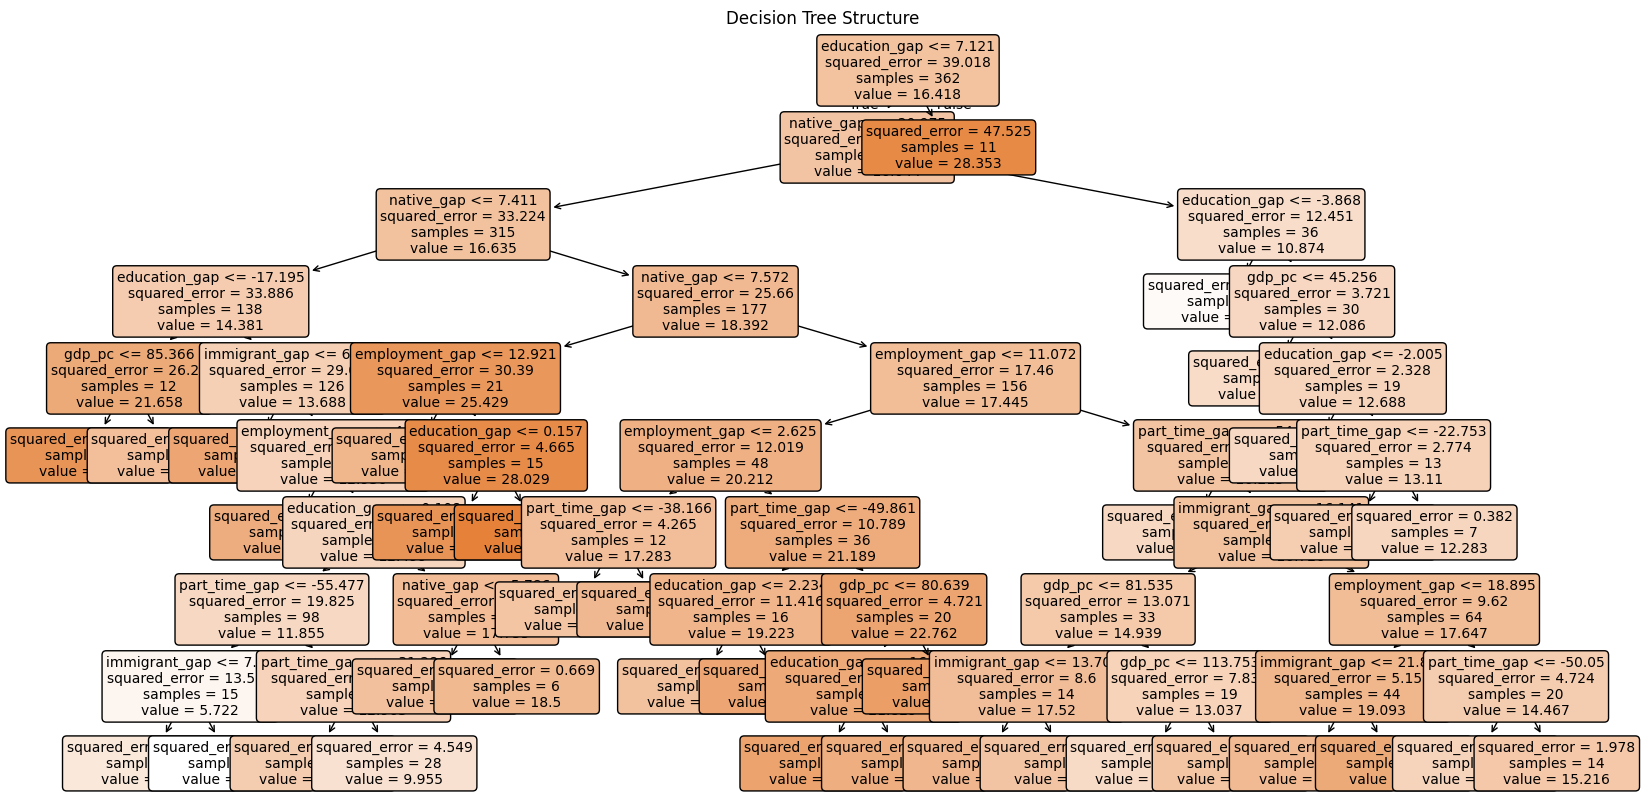

In [12]:
# Display the Decision Tree

plt.figure(figsize=(20, 10))
plot_tree(
    model,
    feature_names=features,
    filled=True,
    rounded=True,
    fontsize=10,
)
plt.title("Decision Tree Structure")
plt.show()

In [13]:
# Save model

with open("models/best_decision_tree.pkl", "wb") as fp:
    pickle.dump(model, fp)

## Train Neural Network

In [14]:
# Convert datasets to 2D PyTorch tensors

X_train_nn = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_nn = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
X_test_nn = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_nn = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

In [15]:
# Define training data batches

batch_size = 10
batch_start = torch.arange(0, X_train_nn.shape[0], batch_size)

In [16]:
# Define the model

# Hyperparameters
learning_rate = 0.005

# Pyramid structure with 6 inputs and two hidden layers
model = nn.Sequential(
    nn.Linear(6, 24),
    nn.ReLU(),
    nn.Linear(24, 12),
    nn.ReLU(),
    nn.Linear(12, 6),
    nn.ReLU(),
    nn.Linear(6, 1)
)

# Loss function: Mean Square Error
loss_fn = nn.MSELoss()

# Optimizer: ADAM
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [17]:
# Training loop

# Variables to hold the best model
best_rmse = np.inf
best_weights = None
history = []

n_epochs = 200

for epoch in range(n_epochs):
    model.train()
    with tqdm.tqdm(batch_start, unit="batch", mininterval=0, disable=True) as bar:
        bar.set_description(f"Epoch {epoch}")
        for start in bar:

            # Pick data batch
            X_batch = X_train_nn[start:start + batch_size]
            y_batch = y_train_nn[start:start + batch_size]

            # Forward pass
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()

            # Update weights
            optimizer.step()

            # Print progress
            bar.set_postfix(mse=float(loss))

    # Measure RMSE at the end of each epoch on the test set
    model.eval()
    y_pred = model(X_test_nn)
    mse = loss_fn(y_pred, y_test_nn)
    rmse = float(mse) ** 0.5
    history.append(rmse)

    # In case of improvement, save model weights
    if rmse < best_rmse:
        best_rmse = rmse
        best_weights = copy.deepcopy(model.state_dict())

# Restore best model weights found
model.load_state_dict(best_weights)

C:\Users\mjvsilva\AppData\Local\Temp\ipykernel_17032\2266826296.py:32: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  bar.set_postfix(mse=float(loss))


<All keys matched successfully>

RMSE: 6.9663


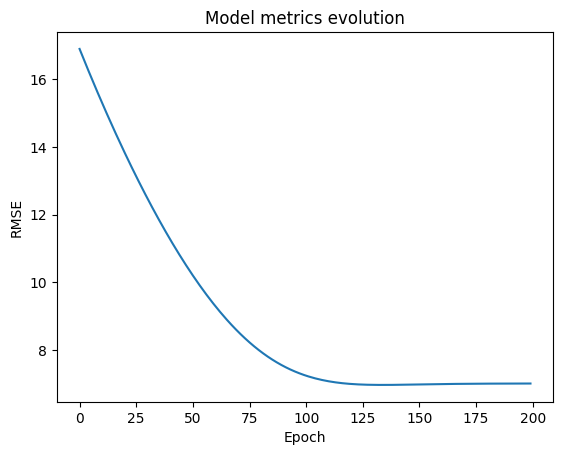

In [18]:
# Display evaluation metrics

print(f"RMSE: {best_rmse:.4f}")
plt.plot(history)
plt.title("Model metrics evolution")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.show()

In [19]:
# Save model

torch.save(model.state_dict(), "models/best_nn_weights.pkl")